In this notebook I am going to try to replicate Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am then going to try to adapt it to work for ALMA Band 5 and Band 7

## Load Intro Things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND6/load_band6_data.py"

In [3]:
%run constants.py

In [4]:
color = ['red', 'blue', 'green']
ls = ['-', '--', '-.']

## Primary Beam and Centre Point

In [5]:
pb_path = band6_data_folder_path + "c2d_989_pbeam_233GHz.fits"

header, _, pb_map, wcs = read_in_file(pb_path)

ny, nx = pb_map.shape

In [6]:
flat_index = np.nanargmax(pb_map)   # ignores NaNs, finds max
y_cen, x_cen = np.unravel_index(flat_index, pb_map.shape)

print(rf'The centre position is: (y, x) = ({y_cen}, {x_cen}), and at this position pb = {pb_map[y_cen, x_cen]}')

The centre position is: (y, x) = (858, 861), and at this position pb = 1.0


In [7]:
dr_arcsec = 0.3 
dr_deg = dr_arcsec / 206265

dr_pix = arcsec_to_pixels(header, 0.3)
dr_pix

16.666666666666664

In [8]:
# pixel radii
r_pix = np.arange(0, nx - x_cen, dr_pix)

# make dataframe
df = pd.DataFrame({"r_pix": r_pix})

df["r_pix_rounded"] = np.round(r_pix)
df["r_arcsec"] = pixels_to_arcsec(header, r_pix)

df["r_deg"] = pixels_to_arcsec(header, r_pix) / 206265

x_pos_arr = []
pb_val_arr = []
sigma_r_arr = []

for i in range(len(r_pix) ):
    
    x_pos = x_cen + int(r_pix[i])
    
    pb_val = pb_map[y_cen, x_pos]
    
    sigma_r = 0.03 / pb_val
    
    
    x_pos_arr.append(x_pos)
    pb_val_arr.append(pb_val)
    sigma_r_arr.append(sigma_r)
    
    
    
    

df["x_pos"] = x_pos_arr
df["pb_val"] = pb_val_arr
df["sigma_r"] = sigma_r_arr


In [9]:
area_annulus_arr = []
area_annulus_arr_v2 = []

for i in range(len(df)):
    
    if i == len(df) - 1:
        area_annulus_arr.append(0)  # no outer annulus for the last bin
        area_annulus_arr_v2.append(0)
    else:
            
        rmin_deg = df["r_deg"][i]
        rmax_deg = df["r_deg"][i + 1]

        # Calculate annulus area in deg^2
        area_annulus = np.pi * (rmax_deg**2 - rmin_deg**2)
        area_annulus_v2 = 2 * np.pi * (rmax_deg + rmin_deg/2) * dr_deg

        area_annulus_arr.append(area_annulus)
        area_annulus_arr_v2.append(area_annulus_v2)
        
df["area_annulus"] = area_annulus_arr
df["area_annulus_v2"] = area_annulus_arr_v2

In [10]:
# Sanity check

print('sigma(r) should be 0.03 at the centre:')
print(rf'When r = {df["r_arcsec"][0]}, sigma(r) = {df["sigma_r"][0]}')

print(' ')

bmaj, bmin, bpa = get_fwhm_from_header(StokesI_header, unit='arcsec')
fwhm = (bmaj * bmin)**0.5
fwhm_idx = (df["r_arcsec"] - fwhm).abs().idxmin()

print('sigma(r) should be 0.06 at the FWHM:')
print(rf'When r = {df["r_arcsec"][fwhm_idx]}, sigma(r) = {df["sigma_r"][fwhm_idx]}')

sigma(r) should be 0.03 at the centre:
When r = 0.0, sigma(r) = 0.03
 
sigma(r) should be 0.06 at the FWHM:
When r = 0.3, sigma(r) = 0.030000082254635317


In [11]:
df

,r_pix,r_pix_rounded,r_arcsec,r_deg,x_pos,pb_val,sigma_r,area_annulus,area_annulus_v2
0,0.000000,0.0,0.0,0.000000,861,1.000000,0.030000,6.645709e-12,1.329142e-11
1,16.666667,17.0,0.3,0.000001,877,0.999997,0.030000,1.993713e-11,3.322854e-11
2,33.333333,33.0,0.6,0.000003,894,0.999946,0.030002,3.322854e-11,5.316567e-11
3,50.000000,50.0,0.9,0.000004,910,0.999730,0.030008,4.651996e-11,7.310280e-11
4,66.666667,67.0,1.2,0.000006,927,0.999113,0.030027,5.981138e-11,9.303992e-11
5,83.333333,83.0,1.5,0.000007,944,0.997864,0.030064,7.310280e-11,1.129770e-10
6,100.000000,100.0,1.8,0.000009,960,0.995856,0.030125,8.639421e-11,1.329142e-10
7,116.666667,117.0,2.1,0.000010,977,0.992678,0.030221,9.968563e-11,1.528513e-10
8,133.333333,133.0,2.4,0.000012,994,0.988343,0.030354,1.129770e-10,1.727884e-10
9,150.000000,150.0,2.7,0.000013,1010,0.983079,0.030516,1.262685e-10,1.927256e-10


In [12]:
# radius_left = radius_array_arcsec


sn_levels = [5, 10 , 20]

prob_band6_norm = []           
prob_band6_cumulative = []  

    
    
for sn in sn_levels: 
    
    prob_annuli = []
    
    
    for i in range(len(df) - 1):
        
        S = sn * df["sigma_r"][i]

        dN_dS_annulus = galaxy_probability(S, 'Band 6')
        dN_dS_mean = np.nanmean(dN_dS_annulus)
        
        # Calculate annulus area in deg^2
        area_annulus = df["area_annulus_v2"][i]
        
        # Expected number of galaxies in annulus
        N = dN_dS_mean * area_annulus
        
        prob_annuli.append(N)  # append to list here
    
    prob_annuli = np.array(prob_annuli)
    
    # Normalize differential probabilities as percentage of total counts
    prob_annuli_norm = 100 * prob_annuli / np.nansum(prob_annuli)
    prob_band6_norm.append(prob_annuli_norm)
    
    # Compute cumulative probability (%)
    cumulative_prob= np.cumsum(prob_annuli_norm)
    prob_band6_cumulative.append(cumulative_prob)
    

In [13]:
sn = 5

# Lists to store quantities
r_list = []
S_list = []
pb_list = []
dN_dS_list = []
N_list = []

for i in range(len(df) - 1):
    r = df["r_arcsec"][i]
    r_list.append(r)
    
    pb = df["sigma_r"][i]
    pb_list.append(pb)

    S = sn * df["sigma_r"][i]
    S_list.append(S)

    dN_dS_annulus = galaxy_probability(S, 'Band 6')
    dN_dS_list.append(dN_dS_annulus)

    area_annulus = df["area_annulus_v2"][i]
    N = dN_dS_annulus * area_annulus
    N_list.append(N)

# Convert to arrays
r_list = np.array(r_list)
S_list = np.array(S_list)
pb_list = np.array(pb_list)
N_list = np.array(N_list)

# Normalize differential probabilities as percentage
prob_annuli_norm = 100 * N_list / np.nansum(N_list)

# Cumulative probability
cumulative_prob = np.cumsum(prob_annuli_norm)

# Create dataframe
df_prob = pd.DataFrame({
    "r_arcsec": r_list,
    "pb": pb_list,
    "S_mJy": S_list,
    "dN_dS_annulus": dN_dS_list,
    "N_expected": N_list * 100,
    "prob_norm": prob_annuli_norm,
    "prob_cumulative": cumulative_prob
})

In [14]:
df_prob

,r_arcsec,pb,S_mJy,dN_dS_annulus,N_expected,prob_norm,prob_cumulative
0,0.0,0.030000,0.150000,257049.250200,0.000342,0.117712,0.117712
1,0.3,0.030000,0.150000,257047.722071,0.000854,0.294278,0.411989
2,0.6,0.030002,0.150008,257018.954264,0.001366,0.470791,0.882781
3,0.9,0.030008,0.150040,256898.851810,0.001878,0.647036,1.529816
4,1.2,0.030027,0.150133,256555.346024,0.002387,0.822399,2.352215
5,1.5,0.030064,0.150321,255860.236077,0.002891,0.995921,3.348136
6,1.8,0.030125,0.150624,254745.239310,0.003386,1.166566,4.514702
7,2.1,0.030221,0.151106,252985.448169,0.003867,1.332284,5.846986
8,2.4,0.030354,0.151769,250595.016030,0.004330,1.491829,7.338815
9,2.7,0.030516,0.152582,247708.572304,0.004774,1.644797,8.983612


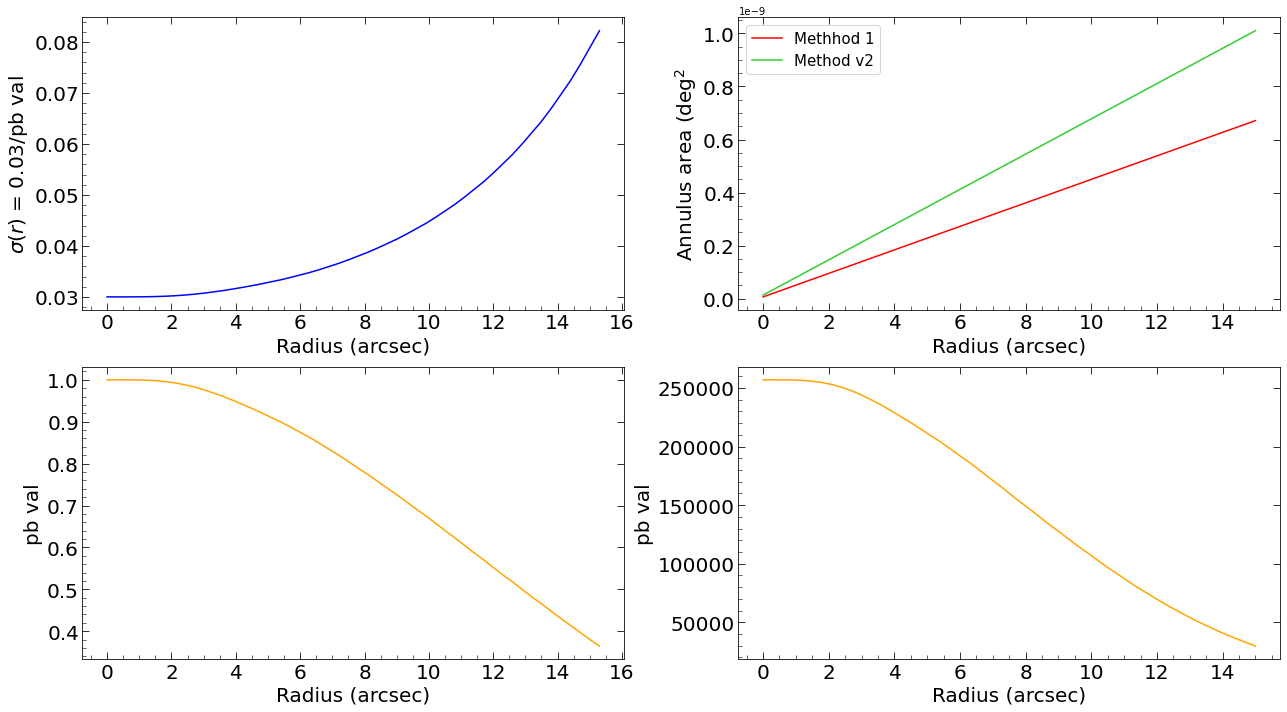

In [15]:
# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(2, 2, figsize=(18,10))


# Top left 
ax[0, 0].plot(df["r_arcsec"], df["sigma_r"], color = 'blue')
ax[0, 0].set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax[0, 0].set_ylabel('$\sigma(r)$ = 0.03/pb val', fontsize=axis_label_fs)


# Top right 
ax[0, 1].plot(df["r_arcsec"].iloc[:-1], df["area_annulus"].iloc[:-1], color = 'red', label = 'Methhod 1')
ax[0, 1].plot(df["r_arcsec"].iloc[:-1], df["area_annulus_v2"].iloc[:-1], color = 'limegreen', label = 'Method v2')
ax[0, 1].set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax[0, 1].set_ylabel('Annulus area (deg$^2$', fontsize=axis_label_fs)
ax[0, 1].legend(fontsize = legend_text_fs)


# Bottom left 
ax[1, 0].plot(df["r_arcsec"], df["pb_val"], color = 'orange')
ax[1, 0].set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax[1, 0].set_ylabel('pb val', fontsize=axis_label_fs)

# Botom Right
ax[1, 1].plot(df_prob["r_arcsec"], df_prob["dN_dS_annulus"], color = 'orange')
ax[1, 1].set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax[1, 1].set_ylabel('pb val', fontsize=axis_label_fs)


for i in range(2):
    for j in range(2):
        ax[i, j].minorticks_on()
        ax[i, j].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
        ax[i, j].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        ax[i, j].tick_params(which='minor', length=4, direction="in")


plt.tight_layout()
plt.show()

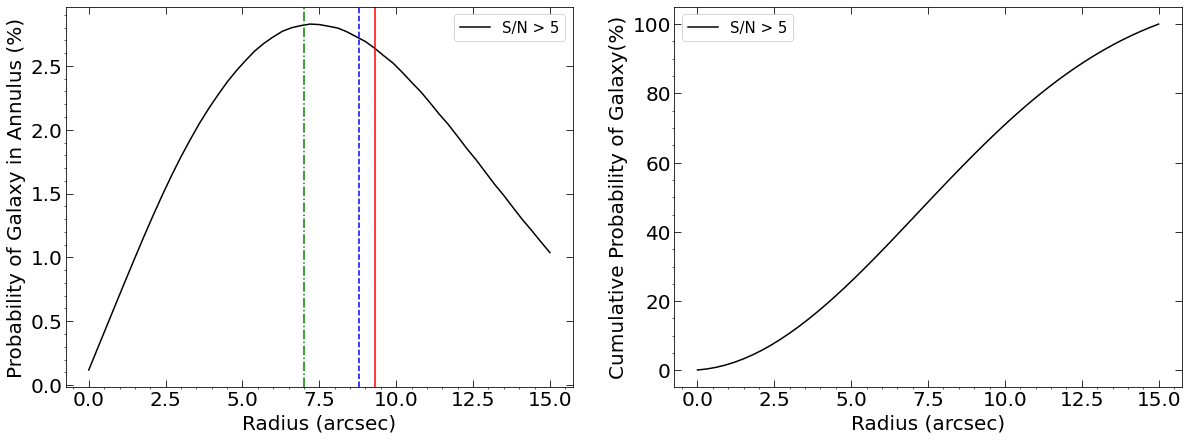

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

N = 5
# Annular detection probability
ax[0].plot(df["r_arcsec"][:-1], prob_annuli_norm, color='black', ls=ls[0], label=f'S/N > {N}')

# Cumulative probability
ax[1].plot(df["r_arcsec"][:-1], cumulative_prob, color='black', ls=ls[0], label=f'S/N > {N}')


ax[0].set_ylabel('Probability of Galaxy in Annulus (%)', fontsize = axis_label_fs)
ax[1].set_ylabel('Cumulative Probability of Galaxy(%)',  fontsize = axis_label_fs)


for i in range(2):
    
    # Add axis labels
    ax[i].set_xlabel(r'Radius (arcsec)', fontsize=axis_label_fs)


    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
    
    ax[i].legend(fontsize = legend_text_fs)

# Mark the peak probability to see if it lines up with the paper
peaks = [9.3, 8.8, 7]
color = ['red', 'blue', 'green']

for i in range(3):
    ax[0].axvline(peaks[i], color = color[i], ls = ls[i])
    

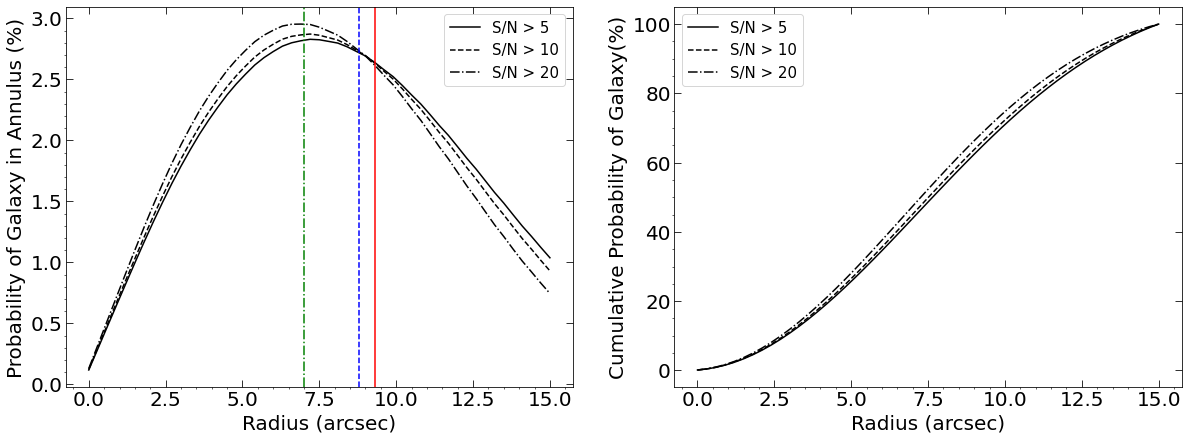

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))


for i, N in enumerate(sn_levels):
    # Annular detection probability
    ax[0].plot(df["r_arcsec"][:-1], prob_band6_norm[i], color='black', ls=ls[i], label=f'S/N > {N}')
    
    # Cumulative probability
    ax[1].plot(df["r_arcsec"][:-1], prob_band6_cumulative[i], color='black', ls=ls[i], label=f'S/N > {N}')


ax[0].set_ylabel('Probability of Galaxy in Annulus (%)', fontsize = axis_label_fs)
ax[1].set_ylabel('Cumulative Probability of Galaxy(%)',  fontsize = axis_label_fs)


for i in range(2):
    
    # Add axis labels
    ax[i].set_xlabel(r'Radius (arcsec)', fontsize=axis_label_fs)


    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
    
    ax[i].legend(fontsize = legend_text_fs)

# Mark the peak probability to see if it lines up with the paper
peaks = [9.3, 8.8, 7]
color = ['red', 'blue', 'green']

for i in range(3):
    ax[0].axvline(peaks[i], color = color[i], ls = ls[i])
    

## Sanity Check

If you print dN/dS (ignore the area term) for let's say r = 10.5 where the pb_corr is 0.78.  That means that the S0 value for the dN/dS equation should be 0.19 for 5sigma, 0.385 for 10sigma, and 0.77 for 20sigma

In [18]:
# Find the index for r = 10.5 in df
index =(df["r_arcsec"] - 5.5).abs().idxmin()

print(rf'At the index of: {index}')
print(rf'     r:  {df["r_arcsec"][index] }')
print(rf'     pb: {df["pb_val"][index]:.2f}')
print(rf'     sigma_r: {df["sigma_r"][index]:.2f}')


print(" ")

print(rf"Sanity Check: ")
print(rf'     sigma_r = 0.03 / pb_val')
print(rf'     0.03 / {df["pb_val"][index]:.2f} = {0.03/df["pb_val"][index]:.2f}')


print(" ")

test_sigma_r = df["sigma_r"][index]


for i in range(len(sn_levels)):
    print(rf'When s = {sn_levels[i]}:')
    
    S = test_sigma_r * sn_levels[i]
    print(rf'     S = {sn_levels[i]} * {test_sigma_r:.2f} = {S:.3f}')
    
    dN_dS = galaxy_probability(S, 'Band 6')
    print(rf'     dN/dS = {dN_dS:.2f}')
    
    print(' ')

At the index of: 18
     r:  5.3999999999999995
     pb: 0.90
     sigma_r: 0.03
 
Sanity Check: 
     sigma_r = 0.03 / pb_val
     0.03 / 0.90 = 0.03
 
When s = 5:
     S = 5 * 0.03 = 0.167
     dN/dS = 204123.68
 
When s = 10:
     S = 10 * 0.03 = 0.334
     dN/dS = 43766.53
 
When s = 20:
     S = 20 * 0.03 = 0.667
     dN/dS = 8507.11
 
